In [1]:
import numpy as np
import torch
import torch.nn as nn

from heston.pinn.heston_pinn_nd import HestonMultiAssetPINN
from utility.model import EarlyStopping
from config.heston_nd import *

In [2]:
seeds = [14]
for seed in seeds:
    print(f'Training model with seed {seed}...')
    pinn = HestonMultiAssetPINN(model_config, seed)
    pinn.set_params(K, r, T, kappa, theta, sigma_bar, sigmas, corr, rho_cross, S_min, S_max, V_min, V_max)
    pinn.set_loss_weights(loss_weights)
    early_stopping = EarlyStopping(patience=1500, min_delta=1e-7)
    pinn.train(batch_size=4096, epochs=40000, early_stopping=early_stopping)
    pinn.save(f'../../models/heston_pinn_nd/{seed}.pth')


Training model with seed 14...
Iteration 0 | Training Loss: 9.423e-02 | Validation Loss: 8.964e-02 | Max interior sq-residual: 1.760e-01
Iteration 500 | Training Loss: 9.772e-04 | Validation Loss: 8.864e-04 | Max interior sq-residual: 1.920e-02
Iteration 1000 | Training Loss: 3.309e-04 | Validation Loss: 3.326e-04 | Max interior sq-residual: 5.599e-03
Iteration 1500 | Training Loss: 1.946e-04 | Validation Loss: 1.955e-04 | Max interior sq-residual: 7.512e-03
Iteration 2000 | Training Loss: 2.154e-04 | Validation Loss: 2.303e-04 | Max interior sq-residual: 2.952e-03
Iteration 2500 | Training Loss: 1.252e-04 | Validation Loss: 1.170e-04 | Max interior sq-residual: 6.129e-03
Iteration 3000 | Training Loss: 9.652e-05 | Validation Loss: 9.345e-05 | Max interior sq-residual: 6.568e-03
Iteration 3500 | Training Loss: 9.378e-05 | Validation Loss: 8.352e-05 | Max interior sq-residual: 5.339e-03
Iteration 4000 | Training Loss: 6.820e-05 | Validation Loss: 6.709e-05 | Max interior sq-residual: 3.

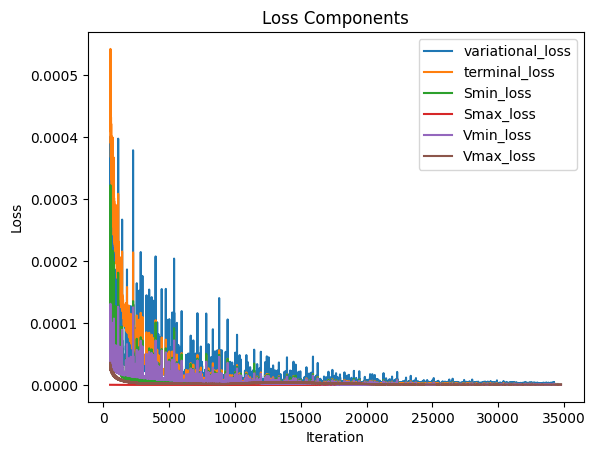

In [3]:
pinn.plot_losses(start_epoch=500, detailed=True)